In [1]:
 # Import all the required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import RANSACRegressor

print("Libraries imported successfully")
print(f"OpenCV version: {cv2.__version__}")
print(f"Numpy version: {np.__version__}")

Libraries imported successfully
OpenCV version: 4.13.0
Numpy version: 2.0.2


In [3]:
# Load the sample image
raw_image = cv2.imread("/content/solidWhiteCurve.jpg")
rgb_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)

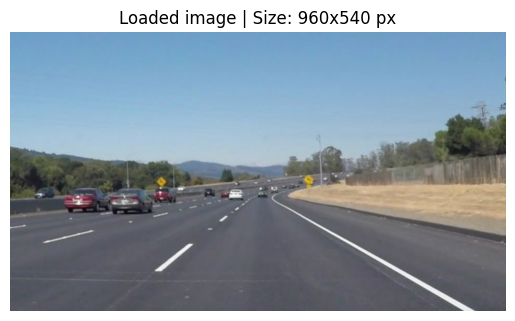

In [4]:
# Display the loaded image
plt.imshow(rgb_image)
plt.title(f"Loaded image | Size: {raw_image.shape[1]}x{raw_image.shape[0]} px")
plt.axis('off')
plt.show()

In [5]:
# Preprocessing pipeline function
# Returns: gray, hls, white_mask, yellow_mask, blended_img, blurred_img
def preprocess_image(rgb_image):
  """
  Pre-processing pipeline:
  1. Converts the image to grayscale
  2. Converts to HLS and extract the L, S channels to enhance white/yellow lines
  3. Combines the images and applies Gaussian Blur
  """

  # Convert to grayscale
  gray = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

  # Convert to hls
  hls = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HLS)
  H, L, S = hls[:,:,0], hls[:,1,:], hls[:,:,2]

  # White line mask
  white_mask = cv2.inRange(hls, np.array([0, 200, 0]),
                                np.array([180, 255, 255]))

  # Yellow line mask
  yellow_mask = cv2.inRange(hls, np.array([15, 38, 115]),
                                 np.array([25, 204, 255]))

  combined_mask = cv2.bitwise_or(white_mask, yellow_mask)
  enhanced_img = cv2.bitwise_and(gray, gray, mask=combined_mask)

  # Blend enchanced_image with grayscale to keep the context
  blended_img = cv2.addWeighted(gray, 0.7, enhanced_img, 0.3, 0)

  # Gaussian blur
  blurred_img = cv2.GaussianBlur(blended_img, (5,5), 0)

  return gray, hls, white_mask, yellow_mask, blended_img, blurred_img

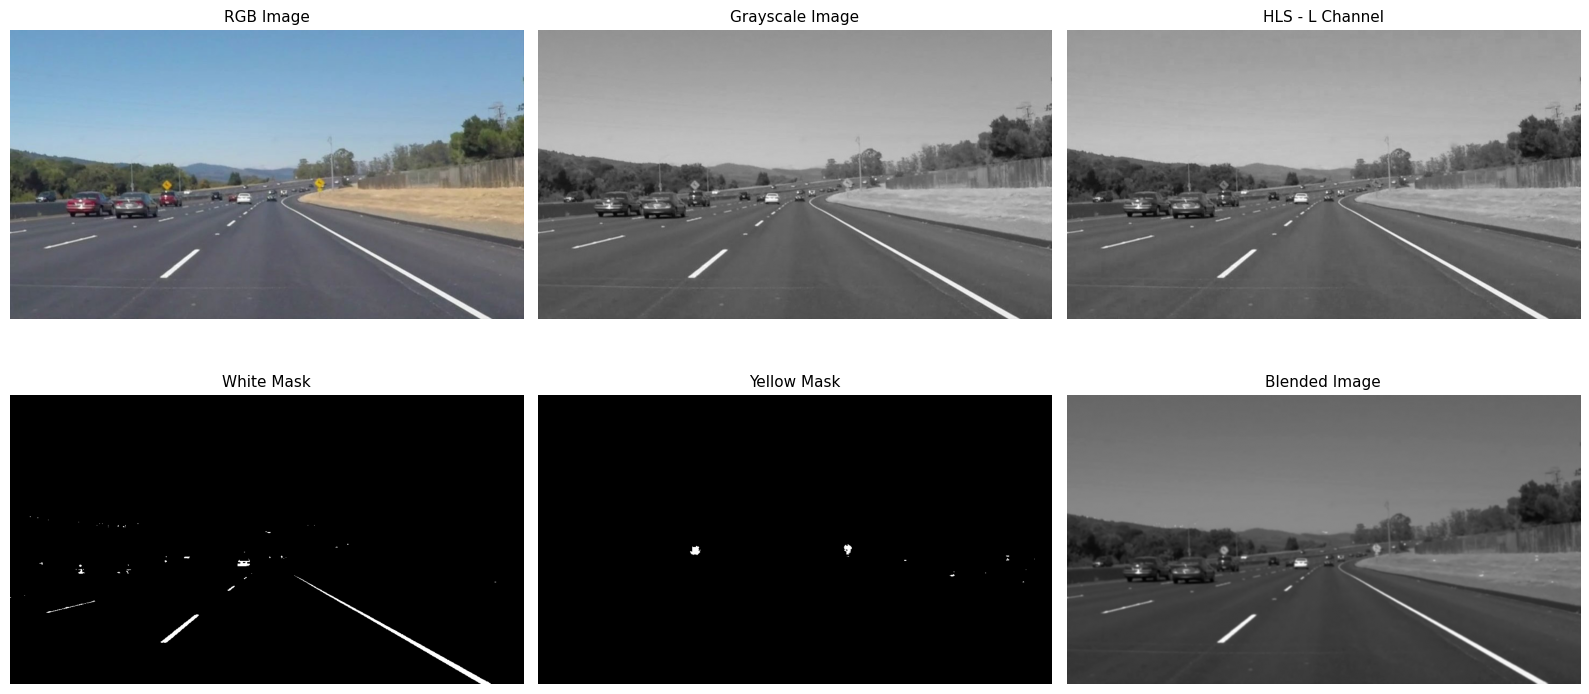

In [6]:
# Preprocessing steps plot
gray, hls, white_mask, yellow_mask, blended_img, blurred_img = preprocess_image(rgb_image)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

imgs = [rgb_image, gray, hls[:,:,1],
        white_mask, yellow_mask, blurred_img]

titles = ["RGB Image", "Grayscale Image", "HLS - L Channel",
         "White Mask", "Yellow Mask", "Blended Image"]

cmaps  = [None, 'gray', 'gray', 'gray', 'gray', 'gray']

for ax, im, title, cm in zip(axes.flat, imgs, titles, cmaps):
    ax.imshow(im, cmap=cm)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

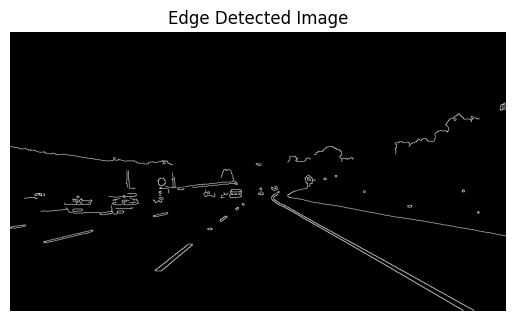

In [7]:
# Canny Edge Detection
TAU_LOW = 50
TAU_HIGH = 150

edges_img = cv2.Canny(blurred_img, TAU_LOW, TAU_HIGH)

plt.title("Edge Detected Image")
plt.imshow(edges_img, cmap='gray')
plt.axis('off')
plt.show()

In [8]:
# ROI - Region of Interest (ROI) Mask
def get_roi_vertices(img_shape):
  """
  Returns a trapezoidal ROI as (row, col) vertices
  """
  h, w = img_shape[:2]
  vertices = np.array([[
      (int(0.05 * w), h),
      (int(0.45 * w), int(0.60 * h)),
      (int(0.55 * w), int(0.60 * h)),
      (int(0.95 * w), h),
  ]], dtype=np.int32)

  return vertices

# Apply ROI Mask
def apply_roi_mask(edge_img, vertices):
  mask = np.zeros_like(edge_img)
  cv2.fillPoly(mask, vertices, 255)
  roi_img = cv2.bitwise_and(edge_img, mask)

  return roi_img

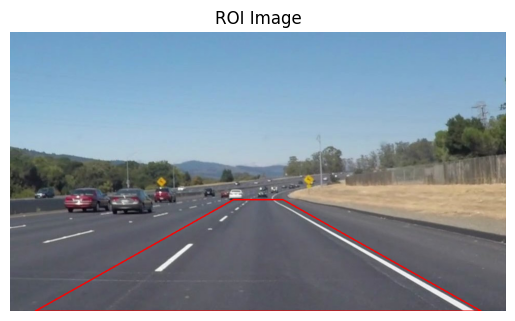

In [9]:
# ROI Vertices
roi_vertices = get_roi_vertices(edges_img.shape)

# ROI image
masked_edges = apply_roi_mask(edges_img, roi_vertices)

# Draw ROI on original image
roi_image = rgb_image.copy()
cv2.polylines(roi_image, roi_vertices, isClosed=True, color=(255, 0, 0), thickness=2)

# Display the image
plt.title("ROI Image")
plt.imshow(roi_image)
plt.axis('off')
plt.show()

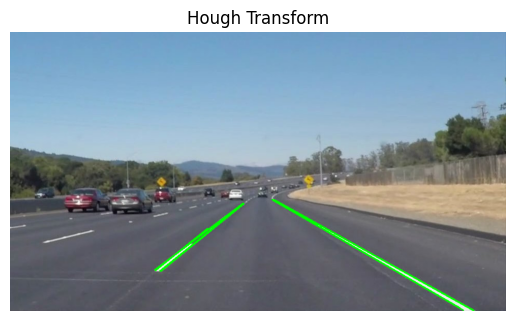

In [10]:
# Hough Transform
RHO = 1
THETA = np.pi / 180
THRESHOLD = 30
MIN_LINE_LEN = 20
MAX_LINE_GAP = 200

line_segments = cv2.HoughLinesP(
    masked_edges,
    rho=RHO,
    theta=THETA,
    threshold=THRESHOLD,
    minLineLength=MIN_LINE_LEN,
    maxLineGap=MAX_LINE_GAP
)

hough_image = rgb_image.copy()
if line_segments is not None:
  for line in line_segments:
    for x1, y1, x2, y2 in line:
      cv2.line(hough_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Display the image
plt.imshow(hough_image)
plt.title("Hough Transform")
plt.axis('off')
plt.show()


In [11]:
# Data clustering and Lane averaging
## Slope calculation

EPSILON = 0.3 # |slope| <= epsilon → discard as horizontal noise

def classify_segments(segments, epsilon=EPSILON):
  """
  For each (x1, y1, x2, y2) segment:
    - compute slope and m intercept b
    - m < -epsilon -> left lane
    - m > epsilon -> right lane
    - |m| <= epsilon -> discard

  Returns: two lists of (m, b) tuples
  """
  left_params, right_params = [], []

  if segments is None:
    return left_params, right_params

  for seg in segments:
    x1, y1, x2, y2 = seg[0]
    if x2 == x1:
      continue
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1

    if m < -epsilon:
      left_params.append((m, b))
    elif m > epsilon:
      right_params.append((m, b))

  return left_params, right_params

In [12]:
left_params, right_params = classify_segments(line_segments)

print(f"Detected line segments  : {len(line_segments) if line_segments is not None else 0}")
print(f"  Left  lane group (m < -eps): {len(left_params)} segments")
print(f"  Right lane group (m > +eps): {len(right_params)} segments")
print(f"  Discarded (|m| ≤ eps = {EPSILON}): "
      f"{(len(line_segments) if line_segments is not None else 0) - len(left_params) - len(right_params)}")

Detected line segments  : 8
  Left  lane group (m < -eps): 4 segments
  Right lane group (m > +eps): 4 segments
  Discarded (|m| ≤ eps = 0.3): 0


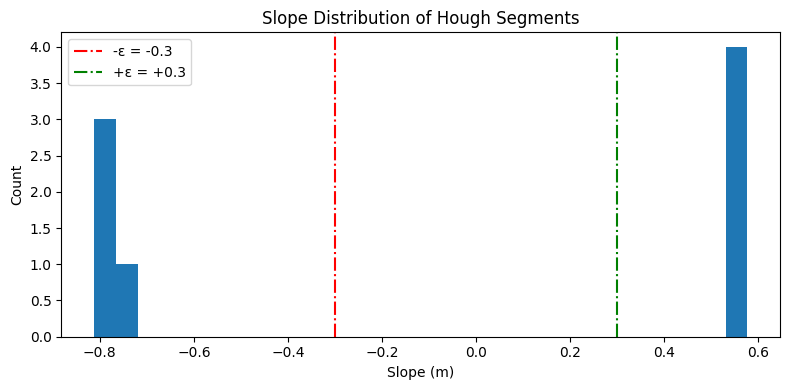

In [13]:
# Show slope distribution
all_slopes = [p[0] for p in left_params + right_params]
plt.figure(figsize=(8, 4))
plt.hist(all_slopes, bins=30)
plt.axvline(-EPSILON, color='red',  linestyle='-.', label=f'-ε = -{EPSILON}')
plt.axvline( EPSILON, color='green', linestyle='-.', label=f'+ε = +{EPSILON}')
plt.xlabel('Slope (m)')
plt.ylabel('Count')
plt.title('Slope Distribution of Hough Segments')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# K-Means clustering
def fit_kmeans(params, k=1):
  if not params or len(params) < k:
    return None

  X = np.array(params)
  km = KMeans(n_clusters=k, random_state=42, n_init='auto')
  km.fit(X)
  centroid = km.cluster_centers_[0]
  return centroid[0], centroid[1]

In [15]:
# TODO: Refactor comments during submission:
# Append to the methods dictionary when we try with the simple averaging and RANSAC
# Fit all methods
methods = {
    "K-Means (k=1)" : (fit_kmeans(left_params), fit_kmeans(right_params))
}

print("ML fitting results")
print(f"{'Method':<22} {'Left  (m, b)':>30}   {'Right (m, b)':>30}")
print("-"*85)
for name, (l, r) in methods.items():
    l_str = f"m={l[0]:.4f}, b={l[1]:.1f}" if l else "None"
    r_str = f"m={r[0]:.4f}, b={r[1]:.1f}" if r else "None"
    print(f"{name:<22} {l_str:>30}   {r_str:>30}")

ML fitting results
Method                                   Left  (m, b)                     Right (m, b)
-------------------------------------------------------------------------------------
K-Means (k=1)                      m=-0.7935, b=688.1                 m=0.5662, b=36.0


In [16]:
# Project lane lines into original image
def make_lane_coordinates(img_shape, line_params, y_start_pct=1.0, y_end_pct=0.60):
  """
  Given (m, b) extrapolate line endpoints across the ROI.
  y_start_pct : fraction of image height for bottom of line (1.0 = bottom)
  y_end_pct   : fraction for top of line (matches ROI top)
  """
  if line_params is None:
    return None
  m, b = line_params
  h = img_shape[0]

  y1 = int(h * y_start_pct)
  y2 = int(h * y_end_pct)
  x1 = int((y1 - b) / m)
  x2 = int((y2 - b) / m)

  return (x1, y1), (x2, y2)

def draw_lane_lines(rgb_image, left_coords, right_coords,
                    left_color=(255, 0, 0), right_color=(0, 0, 255),
                    thickness=4, alpha=0.8):
  overlay = rgb_image.copy()
  if left_coords:
    cv2.line(overlay, left_coords[0], left_coords[1], left_color, thickness)
  if right_coords:
    cv2.line(overlay, right_coords[0], right_coords[1], right_color, thickness)

  return cv2.addWeighted(overlay, alpha, rgb_image, 1-alpha, 0)

In [17]:
Y_START = 1.00
Y_END = 0.61

left_coords = make_lane_coordinates(hough_image.shape, methods["K-Means (k=1)"][0], Y_START, Y_END)
right_coords = make_lane_coordinates(hough_image.shape, methods["K-Means (k=1)"][1], Y_START, Y_END)

lane_image = draw_lane_lines(hough_image, left_coords, right_coords)

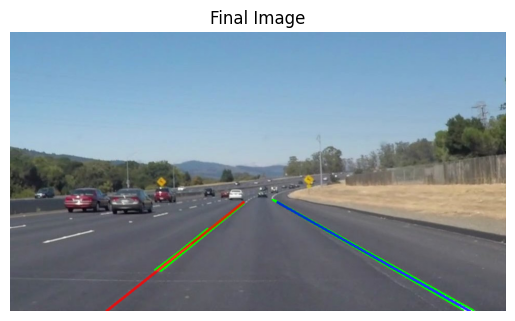

In [18]:
# Display the final image
plt.title("Final Image")
plt.imshow(lane_image)
plt.axis('off')
plt.show()